In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [34]:
def sigmoid(Z):
    return 1/(1+np.exp(-Z))
    

In [35]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 1] = X[:, 1] * 4 + 11.5          # duration: 11.5-15.5 minutes
    X[:, 0] = X[:, 0] * (285 - 150) + 150  # temperature: 150-285 Celsius
    Y = np.zeros(len(X))

    i = 0
    for t, d in X:
        y = -3 / (260 - 175) * t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d <= y):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1, 1))

X, Y = load_coffee_data()

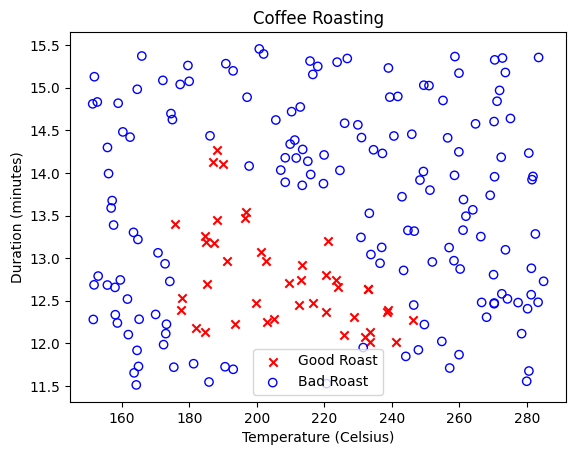

In [36]:
def plot_data(X, Y):
    pos = Y[:, 0] == 1   # good roast
    neg = Y[:, 0] == 0   # bad roast

    plt.scatter(X[pos, 0], X[pos, 1], marker='x', c='red', label='Good Roast')
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', facecolors='none', edgecolors='blue', label='Bad Roast')

    plt.title('Coffee Roasting')
    plt.xlabel('Temperature (Celsius)')
    plt.ylabel('Duration (minutes)')
    plt.legend()
    plt.show()

plot_data(X, Y)

In [6]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51


In [37]:
norm_l=tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)
Xn=norm_l(X)

print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


In [42]:
g=sigmoid  #define activation function

In [38]:
def dense(A_in,W,B):
    Z=np.matmul(A_in,W)+B
    A_out=g(Z)
    return A_out
    

In [39]:
def sequential(X,W1,B1,W2,B2):
    A1=dense(X,W1,B1)
    A2=dense(A1,W2,B2)
    return A2

In [40]:
W1_tmp = np.array( [[-8.93,  0.29, 12.9 ], [-0.1,  -7.32, 10.81]] )
B1_tmp = np.array( [[-9.82, -9.28,  0.96]])
W2_tmp = np.array( [[-31.18], [-27.59], [-32.56]] )
B2_tmp = np.array( [[15.41]] )

#tf trained models param

In [43]:
X_tst = np.array([
    [200,13.9],  # postive example
    [200,17]])   # negative example
X_tstn = norm_l(X_tst)  # remember to normalize
predictions = sequential(X_tstn, W1_tmp, B1_tmp, W2_tmp, B2_tmp)

In [44]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


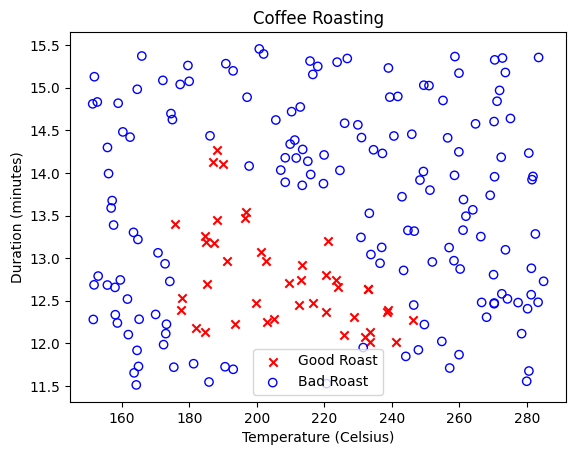

In [45]:
plot_data(X,Y)

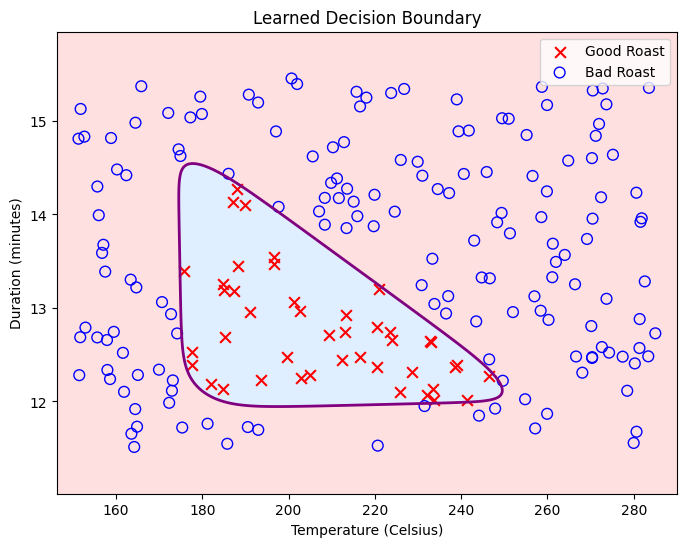

In [48]:
def plot_decision_boundary( norm_l, X, Y):
    # Create a grid covering the range of your original data
    temp_min, temp_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    dur_min, dur_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(temp_min, temp_max, 300),
        np.linspace(dur_min, dur_max, 300)
    )

    # Flatten grid into (N, 2) points, normalize, predict
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_norm = norm_l(grid_points)
    preds = sequential(grid_points_norm, W1_tmp, B1_tmp, W2_tmp, B2_tmp)
    preds = preds.reshape(xx.shape)

    # Plot filled contour for the decision regions
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, levels=[0, 0.5, 1], colors=['#FFCCCC', '#CCE5FF'], alpha=0.6)
    plt.contour(xx, yy, preds, levels=[0.5], colors='purple', linewidths=2)  # the boundary line itself

    # Overlay your original data points
    good = Y[:, 0] == 1
    bad = Y[:, 0] == 0
    plt.scatter(X[good, 0], X[good, 1], c='red', marker='x', label='Good Roast', s=60)
    plt.scatter(X[bad, 0], X[bad, 1], facecolors='none', edgecolors='blue', label='Bad Roast', s=60)

    plt.xlabel('Temperature (Celsius)')
    plt.ylabel('Duration (minutes)')
    plt.title('Learned Decision Boundary')
    plt.legend()
    plt.show()

plot_decision_boundary( norm_l, X, Y)